<a href="https://colab.research.google.com/github/marianoInsa/ONE-TelecomX-2/blob/main/notebooks/03_modelado_predictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Telecom X - Parte 2.3: Modelado Predictivo

Con las features seleccionadas y los datos preparados en los notebooks anteriores, entramos en la fase central del proyecto: **construir modelos de machine learning que predigan qué clientes cancelarán su servicio**.

En la Parte 2.1 transformamos el dataset crudo al formato que los algoritmos requieren (encoding, escalado, balanceo). En la Parte 2.2 identificamos las variables con mayor poder predictivo mediante correlación de Pearson, Información Mutua y análisis de multicolinealidad (VIF). Ahora, con el terreno preparado, pasamos a la acción.

Este notebook se estructura en **tres pasos**:

| Paso | Objetivo |
|---|---|
| **1. Separación de Datos** | Dividir el dataset en entrenamiento y prueba, aplicar balanceo, y generar los artefactos que alimentarán los modelos |
| **2. Creación de Modelos** | Entrenar al menos dos modelos de clasificación con estrategias de normalización diferenciadas |
| **3. Evaluación de los Modelos** | Comparar rendimiento con métricas de clasificación y analizar posibles problemas de overfitting/underfitting |

---
## ⚙️ Configuración del Entorno

In [1]:
# Configuración del path para importar módulos desde src/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Importación de módulos del proyecto
import joblib
import pandas as pd

from src.config import (
    DATA_PROCESSED_DIR,
    MODELS_DIR,
    RANDOM_STATE,
    TEST_SIZE,
    setup_plot_style,
)
from src.preprocessing import (
    load_selected_features,
    scale_features,
    split_and_balance,
)
from src.modeling import train_model, save_model
from src.visualization import plot_smote_comparison

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Aplicar estilo visual
setup_plot_style()
print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


---
## 📥 Carga de Artefactos Previos

Cargamos los dos artefactos generados en los notebooks anteriores:

1. **`telecom_encoded.csv`** (Notebook 01): El dataset completo con todas las variables codificadas numéricamente, listo para ML.
2. **`selected_features.json`** (Notebook 02): La lista de 20 features que superaron el umbral de relevancia ($|r| \geq 0.15$), junto con el registro de las 10 features descartadas.

Este encadenamiento entre notebooks garantiza la **reproducibilidad** del pipeline: cada etapa consume los artefactos de la anterior sin repetir procesamiento.

In [2]:
# Cargar el dataset procesado (Notebook 01)
df_encoded = pd.read_csv(DATA_PROCESSED_DIR / 'telecom_encoded.csv')

print(f'📂 Dataset cargado: {df_encoded.shape[0]} filas × {df_encoded.shape[1]} columnas')
print(f'✅ Todas las columnas son numéricas: {all(df_encoded.dtypes != object)}')

# Cargar las features seleccionadas (Notebook 02)
selected_features = load_selected_features()

df_encoded.head(3)

📂 Dataset cargado: 7043 filas × 31 columnas
✅ Todas las columnas son numéricas: True
📂 Features cargadas desde: selected_features.json
   Método de selección : pearson_abs
   Umbral aplicado     : |r| >= 0.15
   Features retenidas  : 20 columnas


,Churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,customer_gender_Male,...,internet_techsupport_Yes,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,0,...,1,0,1,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0,59.9,542.40,1,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,1,...,0,0,0,0,0,0,0,0,1,0


---
# Paso 1: Separación de Datos

Antes de entrenar cualquier modelo, es imprescindible **dividir el dataset en dos conjuntos independientes**: uno para que el modelo aprenda los patrones (entrenamiento) y otro para evaluar su capacidad de generalización (prueba).

¿Por qué es tan importante? Si evaluamos un modelo con los mismos datos que usó para aprender, obtenemos métricas artificialmente altas que no reflejan su rendimiento real. Es como estudiar con las respuestas del examen: la nota será perfecta, pero no demuestra conocimiento real. Este problema se conoce como **data leakage** y es uno de los errores más comunes (y costosos) en machine learning.

### Decisiones de diseño

| Decisión | Elección | Justificación |
|---|---|---|
| **Proporción** | 80% train / 20% test | Con ~7.043 registros, el 20% (~1.409) provee suficiente masa estadística para una evaluación robusta. Una partición 70/30 sería igualmente válida, pero reduciría los datos disponibles para entrenamiento sin beneficio significativo en la evaluación. |
| **Estratificación** | `stratify=y` | Garantiza que ambos conjuntos mantengan la misma proporción de churn (~26.5%) que el dataset original. Sin estratificar, el azar podría generar un test set con una distribución atípica, invalidando las métricas. |
| **Balanceo (SMOTE)** | Solo en train | Los ejemplos sintéticos se generan exclusivamente sobre el conjunto de entrenamiento. El test set preserva la distribución real del mundo para que la evaluación sea fiel. |
| **Escalado pre-SMOTE** | `StandardScaler` antes de SMOTE | SMOTE utiliza distancia euclidiana (k-NN) para interpolar vecinos. Sin escalar, features con rangos amplios (como `account_charges_total`) dominarían el cálculo, sesgando los ejemplos sintéticos. **Este escalado es un requisito técnico de SMOTE**, no una decisión de normalización para los modelos — esa decisión se tomará en el Paso 2. |
| **Semilla** | `RANDOM_STATE = 42` | Semilla fija para reproducibilidad total. Cualquier re-ejecución produce exactamente los mismos conjuntos. |

---
## 1.1 División Estratificada y Balanceo (Split → Scale → SMOTE)

El pipeline completo se ejecuta en un solo paso a través de la función `split_and_balance()`, que encapsula la secuencia correcta:

```
Dataset completo
      │
      ▼
  train_test_split(stratify=y)  ─── 80% Train ───┐
      │                                          │
      │                                    StandardScaler
      │                                    (fit en train)
      │                                          │
      │                                        SMOTE
      │                                    (solo en train)
      │                                          │
      ▼                                          ▼
   20% Test                               Train balanceado
  (escalado)                                 (escalado)
Distribución real                            50% / 50%
```

El scaler se ajusta (fit) **exclusivamente** en el train set y se aplica (transform) a ambos conjuntos, previniendo cualquier fuga de información del test al proceso de escalado.

In [3]:
# Separación de features y variable objetivo
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Pipeline integrado: split estratificado → escalado → SMOTE
split = split_and_balance(X, y, apply_smote=True, scale_before_smote=True)

# Desempaquetar artefactos
X_train_bal = split.X_train_bal     # Escalado + balanceado (para entrenamiento)
y_train_bal = split.y_train_bal
X_test      = split.X_test          # Escalado (test real, sin modificar distribución)
y_test      = split.y_test
X_train     = split.X_train         # Train original sin escalar ni balancear (referencia)
y_train     = split.y_train
scaler      = split.scaler          # StandardScaler ajustado en train

=== División Train / Test ===
  Train : 5634 registros  (80.0%)
  Test  : 1409  registros  (20.0%)
  Features: 30 columnas

  Distribución en Train | Churn: 26.54%
  Distribución en Test  | Churn: 26.54%
=== Verificación del escalado (Train) ===
  Media promedio de todas las features : 0.000000  (esperado ≈ 0)
  Std  promedio de todas las features  : 1.000000  (esperado ≈ 1)

  Shape X_train_scaled : (5634, 30)
  Shape X_test_scaled  : (1409, 30)

✅ Estandarización completada.

✅ Escalado aplicado ANTES de SMOTE (distancia euclidiana corregida).

=== Distribución después de SMOTE (Train) ===
  Clase 0 | No canceló :  4139 registros (50.0%)
  Clase 1 | Canceló    :  4139 registros (50.0%)

  Ejemplos sintéticos generados: 2644 nuevos registros de churn

✅ Test set permanece intacto: 1409 registros (sin modificar)


---
## 1.2 Verificación de la Estratificación

Confirmamos que `stratify=y` cumplió su función: la proporción de churn debe ser prácticamente idéntica en el dataset original, el train set (pre-SMOTE) y el test set.

In [4]:
print('=== Verificación de Estratificación ===')
print(f'{"Conjunto":<25} {"Registros":>10} {"Churn %":>10}')
print('-' * 47)
print(f'{"Dataset original":<25} {len(y):>10,} {y.mean():>10.2%}')
print(f'{"Train (pre-SMOTE)":<25} {len(y_train):>10,} {y_train.mean():>10.2%}')
print(f'{"Test":<25} {len(y_test):>10,} {y_test.mean():>10.2%}')
print('-' * 47)

diff = abs(y_train.mean() - y_test.mean())
print(f'\n  Diferencia train-test: {diff:.4f} ({"✅ < 1%" if diff < 0.01 else "⚠️ > 1%"})')
print(f'  Proporción de churn preservada en ambos conjuntos.')

=== Verificación de Estratificación ===
Conjunto                   Registros    Churn %
-----------------------------------------------
Dataset original               7,043     26.54%
Train (pre-SMOTE)              5,634     26.54%
Test                           1,409     26.54%
-----------------------------------------------

  Diferencia train-test: 0.0001 (✅ < 1%)
  Proporción de churn preservada en ambos conjuntos.


---
## 1.3 Efecto del Balanceo (SMOTE)

En el notebook 01 detectamos un desbalance de **~2.77:1** (No Churn / Churn). Sin corregirlo, los modelos tenderían a predecir siempre la clase mayoritaria ("el cliente se queda"), logrando una accuracy engañosa del ~73% pero fallando en detectar los casos de churn — que son precisamente los que Telecom X necesita identificar.

SMOTE (Synthetic Minority Oversampling Technique) generó ejemplos sintéticos de la clase minoritaria interpolando entre vecinos cercanos, **solo dentro del train set**. El test set mantiene su distribución real (~26.5% churn) para que la evaluación sea representativa del mundo real.

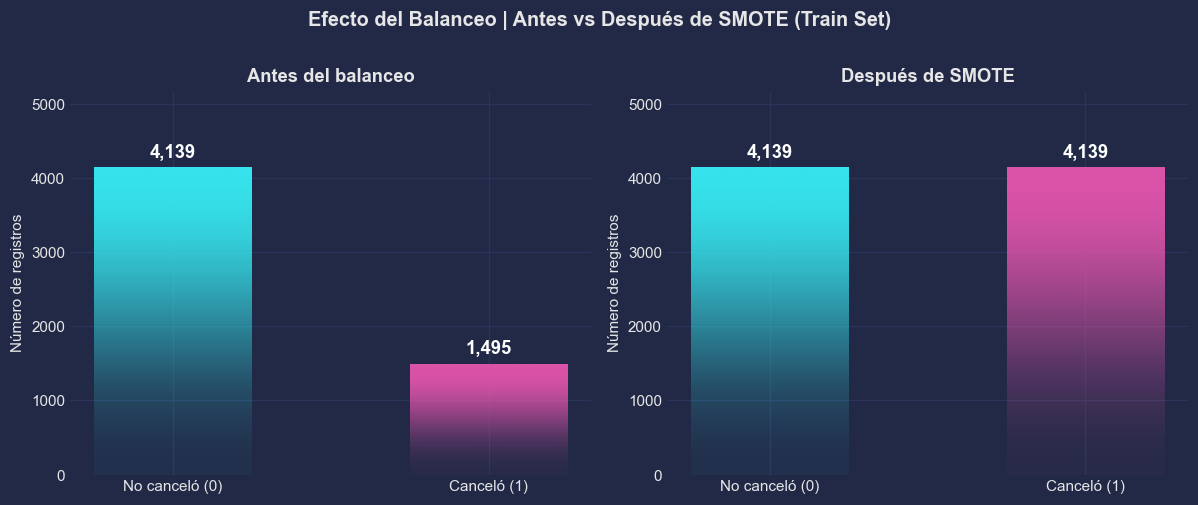

In [5]:
plot_smote_comparison(y_train, y_train_bal)

---
## 1.4 Artefactos Disponibles para el Modelado

El pipeline de separación generó todos los conjuntos necesarios para entrenar y evaluar modelos en los pasos siguientes. A continuación, un inventario completo:

| Variable | Descripción | Dimensiones | Uso previsto |
|---|---|---|---|
| `X_train_bal`, `y_train_bal` | Train escalado + balanceado (todas las features) | — | Entrenamiento de todos los modelos |
| `X_test`, `y_test` | Test escalado (distribución real sin modificar) | — | Evaluación de todos los modelos |
| `X_train`, `y_train` | Train original sin escalar ni balancear | — | Referencia y comparación |
| `selected_features` | Lista de 20 features | 20 cols | Filtrado en Paso 2 para modelos que lo requieran |
| `scaler` | `StandardScaler` ajustado en train | — | Transformar nuevos datos en producción |

> **Nota sobre la estrategia dual de features:** El notebook 02 estableció que los modelos basados en árboles (Random Forest, etc.) pueden usar todas las features, mientras que los modelos sensibles a escala (Regresión Logística, etc.) se benefician de usar solo las features seleccionadas. El filtrado concreto (`X_train_bal[selected_features]`) se aplicará en el Paso 2 según el modelo que se entrene.

In [6]:
print('=== Dimensiones de los artefactos ===')
print(f'{"Artefacto":<25} {"Shape":>20}')
print('-' * 47)
print(f'{"X_train_bal":<25} {str(X_train_bal.shape):>20}')
print(f'{"y_train_bal":<25} {str(y_train_bal.shape):>20}')
print(f'{"X_test":<25} {str(X_test.shape):>20}')
print(f'{"y_test":<25} {str(y_test.shape):>20}')
print(f'{"X_train (referencia)":<25} {str(X_train.shape):>20}')
print(f'{"y_train (referencia)":<25} {str(y_train.shape):>20}')
print('-' * 47)
print(f'{"selected_features":<25} {len(selected_features):>17} cols')
print(f'{"scaler":<25} {type(scaler).__name__:>20}')

=== Dimensiones de los artefactos ===
Artefacto                                Shape
-----------------------------------------------
X_train_bal                         (8278, 30)
y_train_bal                            (8278,)
X_test                              (1409, 30)
y_test                                 (1409,)
X_train (referencia)                (5634, 30)
y_train (referencia)                   (5634,)
-----------------------------------------------
selected_features                        20 cols
scaler                          StandardScaler


---
## 💾 Persistencia de Artefactos

Guardamos los conjuntos de datos y el scaler en disco para garantizar la **reproducibilidad** del pipeline. Esto permite:
- Re-ejecutar los pasos de modelado y evaluación sin necesidad de repetir la separación.
- Consumir los mismos datos desde otros notebooks o scripts.
- Reutilizar el scaler para transformar nuevos datos en producción.

Los CSVs se guardan en `data/processed/` y el scaler serializado en `models/`, siguiendo las convenciones del proyecto.

In [7]:
# Persistir conjuntos de datos
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train_bal.to_csv(DATA_PROCESSED_DIR / 'X_train_bal.csv', index=False)
y_train_bal.to_csv(DATA_PROCESSED_DIR / 'y_train_bal.csv', index=False)
X_test.to_csv(DATA_PROCESSED_DIR / 'X_test.csv', index=False)
y_test.to_csv(DATA_PROCESSED_DIR / 'y_test.csv', index=False)

# Persistir el scaler para producción
scaler_path = MODELS_DIR / 'scaler_modelado.pkl'
joblib.dump(scaler, scaler_path)

print('✅ Artefactos exportados:')
print(f'   📁 data/processed/X_train_bal.csv  ({X_train_bal.shape})')
print(f'   📁 data/processed/y_train_bal.csv  ({y_train_bal.shape})')
print(f'   📁 data/processed/X_test.csv       ({X_test.shape})')
print(f'   📁 data/processed/y_test.csv       ({y_test.shape})')
print(f'   📁 models/scaler_modelado.pkl      ({type(scaler).__name__})')

✅ Artefactos exportados:
   📁 data/processed/X_train_bal.csv  ((8278, 30))
   📁 data/processed/y_train_bal.csv  ((8278,))
   📁 data/processed/X_test.csv       ((1409, 30))
   📁 data/processed/y_test.csv       ((1409,))
   📁 models/scaler_modelado.pkl      (StandardScaler)


---
## ✅ Resumen del Paso 1: Separación de Datos

El dataset fue dividido y transformado siguiendo un pipeline riguroso que previene data leakage en cada etapa:

| Paso | Acción | Justificación |
|---|---|---|
| **Split 80/20** | `train_test_split` con `stratify=y` | Proporción de churn preservada (~26.5%) en ambos conjuntos |
| **Escalado** | `StandardScaler` (fit solo en train) | Requisito técnico de SMOTE: distancia euclidiana equitativa |
| **SMOTE** | Balanceo 50/50 solo en train | Corrige desbalance 2.77:1 sin contaminar el test set |
| **Persistencia** | CSVs + scaler serializado | Reproducibilidad total del pipeline |

### Artefactos generados

| Archivo | Ubicación | Contenido |
|---|---|---|
| `X_train_bal.csv` | `data/processed/` | Features de entrenamiento (escaladas + balanceadas) |
| `y_train_bal.csv` | `data/processed/` | Target de entrenamiento (balanceado 50/50) |
| `X_test.csv` | `data/processed/` | Features de prueba (escaladas, distribución real) |
| `y_test.csv` | `data/processed/` | Target de prueba (distribución real ~26.5% churn) |
| `scaler_modelado.pkl` | `models/` | Scaler para transformar nuevos datos en producción |

Con los datos correctamente separados y balanceados, estamos listos para el siguiente paso: entrenar modelos de clasificación que aprendan a distinguir entre clientes que permanecen y los que cancelan.

---
# Paso 2: Creación de Modelos

Con los datos divididos, escalados y balanceados, pasamos a la fase de construcción de modelos predictivos. Entrenaremos **dos modelos complementarios** que representan filosofías de aprendizaje fundamentalmente distintas:

| Modelo | Familia | Enfoque | Fortaleza |
|---|---|---|---|
| **Regresión Logística** | Lineal | Busca un hiperplano que separe las clases | Interpretable, rápido, coeficientes con significado directo |
| **Random Forest** | Ensemble de árboles | Combina múltiples árboles de decisión | Captura relaciones no lineales e interacciones entre variables |

Esta diversidad no es arbitraria: un modelo lineal nos dice *qué variables empujan hacia el churn y cuánto*, mientras que un ensemble de árboles puede descubrir *combinaciones de factores* que el modelo lineal no puede capturar. Compararlos revela si los patrones de churn son principalmente lineales o involucran interacciones más complejas.

---
## 2.1 Estrategia de Normalización

Una de las decisiones más importantes al seleccionar modelos es si los datos deben estar **normalizados** (escalados a media 0 y desviación estándar 1). La respuesta depende del algoritmo:

| Modelo | ¿Requiere normalización? | ¿Por qué? |
|---|---|---|
| **Regresión Logística** | ✅ Sí | El algoritmo de optimización (gradient descent) converge más rápido y los **coeficientes son comparables** entre features. Sin escalar, una variable como `account_charges_total` (rango 0–8500) dominaría sobre `customer_seniorcitizen` (0/1), produciendo coeficientes que reflejan la escala y no la importancia real. |
| **Random Forest** | ❌ No | Los árboles de decisión dividen datos mediante **umbrales** sobre cada variable individual. Estas particiones son invariantes a transformaciones monótonas: escalar o no los datos produce exactamente los mismos splits y, por tanto, las mismas predicciones. |

### ¿Necesitamos re-escalar?

**No.** En el Paso 1, los datos ya fueron estandarizados con `StandardScaler` como requisito técnico de SMOTE (que usa distancia euclidiana). Este escalado cumple la doble función:

1. **Para SMOTE:** Garantiza que los vecinos se calculen en un espacio equitativo.
2. **Para Regresión Logística:** Asegura convergencia del optimizador y coeficientes interpretables.

Para Random Forest, el escalado simplemente no tiene efecto — los splits producen resultados idénticos con o sin él. Por tanto, **ambos modelos pueden entrenarse sobre los mismos datos escalados** sin perjuicio para ninguno.

---
## 2.2 Modelo A: Regresión Logística

La Regresión Logística es el **baseline natural** para clasificación binaria. A pesar de su nombre, no es un modelo de regresión: estima la probabilidad de pertenecer a la clase positiva (churn) mediante una función sigmoide aplicada a una combinación lineal de las features.

### ¿Por qué Regresión Logística?

- **Interpretabilidad directa:** Cada coeficiente indica cuánto y en qué dirección contribuye una variable al riesgo de churn. Un coeficiente positivo alto en `internet_internetservice_Fiber optic` significa que tener fibra óptica aumenta la probabilidad de cancelación.
- **Baseline robusto:** Si un modelo más complejo no supera significativamente a la regresión logística, la complejidad adicional no se justifica.
- **Compatibilidad con normalización:** Los datos ya están escalados (StandardScaler), lo que garantiza que el optimizador converja correctamente y que los coeficientes reflejen la importancia real de cada variable, no su escala.

### ¿Por qué solo las features seleccionadas?

Usamos las **20 features** que superaron el umbral $|r| \geq 0.15$ en el notebook 02. Para un modelo lineal, incluir variables con baja correlación:
- **Infla la varianza** de los coeficientes (más parámetros a estimar con la misma cantidad de datos).
- **Introduce ruido** que puede degradar la calibración de las probabilidades.
- **Aumenta la multicolinealidad**, distorsionando la interpretación de los coeficientes.

In [8]:
# Filtrar features seleccionadas para Regresión Logística
X_train_lr = X_train_bal[selected_features]
X_test_lr  = X_test[selected_features]

print(f'Features para Regresión Logística: {X_train_lr.shape[1]} columnas (seleccionadas)')

# Instanciar y entrenar
lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,          # Previene warnings de no-convergencia
)
lr_model = train_model(lr_model, X_train_lr, y_train_bal, model_name='Regresión Logística')

# Generar predicciones (para evaluación en Paso 3)
y_pred_lr_train = lr_model.predict(X_train_lr)
y_pred_lr       = lr_model.predict(X_test_lr)

print(f'\n📊 Predicciones generadas: {len(y_pred_lr)} (test) | {len(y_pred_lr_train)} (train)')

# Persistir modelo
save_model(lr_model, 'logistic_regression');

Features para Regresión Logística: 20 columnas (seleccionadas)
=== Entrenando: Regresión Logística ===
  Samples  : 8,278
  Features : 20
  Tiempo   : 0.03s

✅ Regresión Logística entrenado correctamente.

📊 Predicciones generadas: 1409 (test) | 8278 (train)
💾 Modelo guardado: models\logistic_regression.pkl


---
## 2.3 Modelo B: Random Forest

Random Forest es un **ensemble de árboles de decisión**: entrena múltiples árboles sobre subconjuntos aleatorios de los datos y las features, y combina sus predicciones por votación mayoritaria. Esta arquitectura le otorga propiedades que complementan las debilidades de la regresión logística.

### ¿Por qué Random Forest?

- **Captura relaciones no lineales:** Si el churn depende de *combinaciones* de factores (ej. tenure bajo **y** contrato mensual **y** fibra óptica), un árbol puede aprender estos patrones directamente. La regresión logística solo modela efectos aditivos.
- **Robusto ante features irrelevantes:** Cada árbol usa un subconjunto aleatorio de features (feature bagging). Las variables sin poder predictivo rara vez son seleccionadas para splits, por lo que no degradan el rendimiento.
- **No requiere normalización:** Los splits de un árbol comparan valores contra umbrales. $x > 5000$ produce la misma partición que $z > 0.58$ (su versión escalada). El escalado es transparente.

### ¿Por qué todas las features?

Usamos las **30 features completas** del dataset codificado. A diferencia de la regresión logística:
- Los árboles **ignoran automáticamente** features sin poder predictivo (no las seleccionan para splits).
- Incluir todas las features maximiza la probabilidad de **capturar interacciones** que podrían haber quedado fuera de la selección por correlación lineal.
- El feature bagging previene el overfitting incluso con features redundantes.

In [9]:
# Random Forest usa todas las features (30 columnas)
X_train_rf = X_train_bal
X_test_rf  = X_test

print(f'Features para Random Forest: {X_train_rf.shape[1]} columnas (todas)')

# Instanciar y entrenar
rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 árboles (default sklearn, buen balance rendimiento/tiempo)
    random_state=RANDOM_STATE,
)
rf_model = train_model(rf_model, X_train_rf, y_train_bal, model_name='Random Forest')

# Generar predicciones (para evaluación en Paso 3)
y_pred_rf_train = rf_model.predict(X_train_rf)
y_pred_rf       = rf_model.predict(X_test_rf)

print(f'\n📊 Predicciones generadas: {len(y_pred_rf)} (test) | {len(y_pred_rf_train)} (train)')

# Persistir modelo
save_model(rf_model, 'random_forest');

Features para Random Forest: 30 columnas (todas)
=== Entrenando: Random Forest ===
  Samples  : 8,278
  Features : 30
  Tiempo   : 1.05s

✅ Random Forest entrenado correctamente.

📊 Predicciones generadas: 1409 (test) | 8278 (train)
💾 Modelo guardado: models\random_forest.pkl


---
## ✅ Resumen del Paso 2: Creación de Modelos

Se entrenaron dos modelos de clasificación con filosofías complementarias:

| Aspecto | Regresión Logística | Random Forest |
|---|---|---|
| **Familia** | Lineal | Ensemble de árboles |
| **Features** | 20 seleccionadas ($\|r\| \geq 0.15$) | 30 (todas) |
| **Normalización** | ✅ Requerida (ya aplicada en Paso 1) | ❌ No necesaria (invariante a escala) |
| **Hiperparámetros** | `max_iter=1000` | `n_estimators=100` |
| **Fortaleza** | Interpretabilidad, coeficientes directos | Relaciones no lineales, interacciones |

### Artefactos generados

| Archivo | Ubicación | Contenido |
|---|---|---|
| `logistic_regression.pkl` | `models/` | Modelo de Regresión Logística entrenado |
| `random_forest.pkl` | `models/` | Modelo de Random Forest entrenado |

### Variables disponibles para el Paso 3

| Variable | Descripción |
|---|---|
| `y_pred_lr`, `y_pred_lr_train` | Predicciones de Regresión Logística (test y train) |
| `y_pred_rf`, `y_pred_rf_train` | Predicciones de Random Forest (test y train) |
| `lr_model`, `rf_model` | Modelos ajustados (para inspeccionar coeficientes, importancias, etc.) |

Con ambos modelos entrenados y sus predicciones generadas, estamos listos para el paso final: evaluar y comparar su rendimiento.

---
# Paso 3: Evaluación de los Modelos

Con ambos modelos entrenados y sus predicciones generadas, es momento de **medir qué tan bien clasifican** a los clientes que cancelarán el servicio.

Evaluaremos cada modelo con cinco métricas de clasificación estándar:

- **Accuracy** — proporción global de aciertos.
- **Precision** — de los clientes marcados como *churn*, ¿cuántos realmente cancelaron?
- **Recall** — de los clientes que *realmente* cancelaron, ¿cuántos detectamos?
- **F1-score** — media armónica entre Precision y Recall (equilibra ambas).
- **Confusion Matrix** — desglose completo de TP, FP, TN, FN.

Finalmente, compararemos los modelos entre sí y diagnosticaremos si alguno presenta **overfitting** (memoriza sin generalizar) o **underfitting** (no captura los patrones subyacentes).

## 3.1 ¿Qué mide cada métrica?

En un problema de **churn**, no todas las métricas pesan igual. Veamos su significado en contexto de negocio:

| Métrica | Fórmula | Interpretación en Churn |
|---|---|---|
| **Accuracy** | $\frac{TP + TN}{Total}$ | Proporción global de predicciones correctas. Puede ser engañosa con clases desbalanceadas. |
| **Precision** | $\frac{TP}{TP + FP}$ | De los clientes que el modelo marca como "va a cancelar", ¿cuántos realmente cancelan? Alta precision → pocas alarmas falsas. |
| **Recall** | $\frac{TP}{TP + FN}$ | De los clientes que **sí cancelan**, ¿cuántos detectamos? Alto recall → pocos churners escapan. |
| **F1-score** | $\frac{2 \cdot P \cdot R}{P + R}$ | Balance entre Precision y Recall. Útil cuando ambos importan. |
| **Confusion Matrix** | — | Tabla 2×2 con el conteo de TP, FP, TN, FN para análisis detallado. |

> **💡 En retención de clientes, el Recall suele ser la métrica más valiosa**: es mejor contactar a un cliente que no iba a cancelar (falso positivo) que perder a uno que sí iba a hacerlo (falso negativo).

In [10]:
# --- Paso 3: Imports y configuración ---
import matplotlib.pyplot as plt
from src.modeling import evaluate_model
from src.visualization import (
    plot_confusion_matrix,
    plot_metrics_comparison,
    plot_overfit_analysis,
    plot_roc_curves,
)

## 3.2 Evaluación: Regresión Logística

Comenzamos con el modelo lineal. Evaluamos sus predicciones tanto en el **test set** (capacidad de generalización) como en el **train set** (para diagnosticar overfitting más adelante).

In [11]:
# Probabilidades para curvas ROC
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]
y_proba_lr_train = lr_model.predict_proba(X_train_lr)[:, 1]

eval_lr = evaluate_model(
    "Regresión Logística",
    y_test,
    y_pred_lr,
    y_train_true=y_train_bal,
    y_pred_train=y_pred_lr_train,
    y_proba_test=y_proba_lr,
    y_proba_train=y_proba_lr_train,
)

  📊 Evaluación: Regresión Logística

  ▸ Test set
    Accuracy  : 0.7473
    Precision : 0.5156
    Recall    : 0.7941
    F1-score  : 0.6253
    ROC AUC   : 0.8400

  ▸ Train set
    Accuracy  : 0.7755
    Precision : 0.7524
    Recall    : 0.8215
    F1-score  : 0.7854
    ROC AUC   : 0.8563



## 3.3 Evaluación: Random Forest

Repetimos el proceso para el modelo de ensemble. Al usar todas las features (30), esperamos que el modelo capture interacciones no lineales que la regresión logística no puede modelar.

In [12]:
# Probabilidades para curvas ROC
y_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]
y_proba_rf_train = rf_model.predict_proba(X_train_rf)[:, 1]

eval_rf = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_train_true=y_train_bal,
    y_pred_train=y_pred_rf_train,
    y_proba_test=y_proba_rf,
    y_proba_train=y_proba_rf_train,
)

  📊 Evaluación: Random Forest

  ▸ Test set
    Accuracy  : 0.7807
    Precision : 0.5876
    Recall    : 0.5829
    F1-score  : 0.5852
    ROC AUC   : 0.8213

  ▸ Train set
    Accuracy  : 0.9984
    Precision : 0.9981
    Recall    : 0.9988
    F1-score  : 0.9984
    ROC AUC   : 1.0000



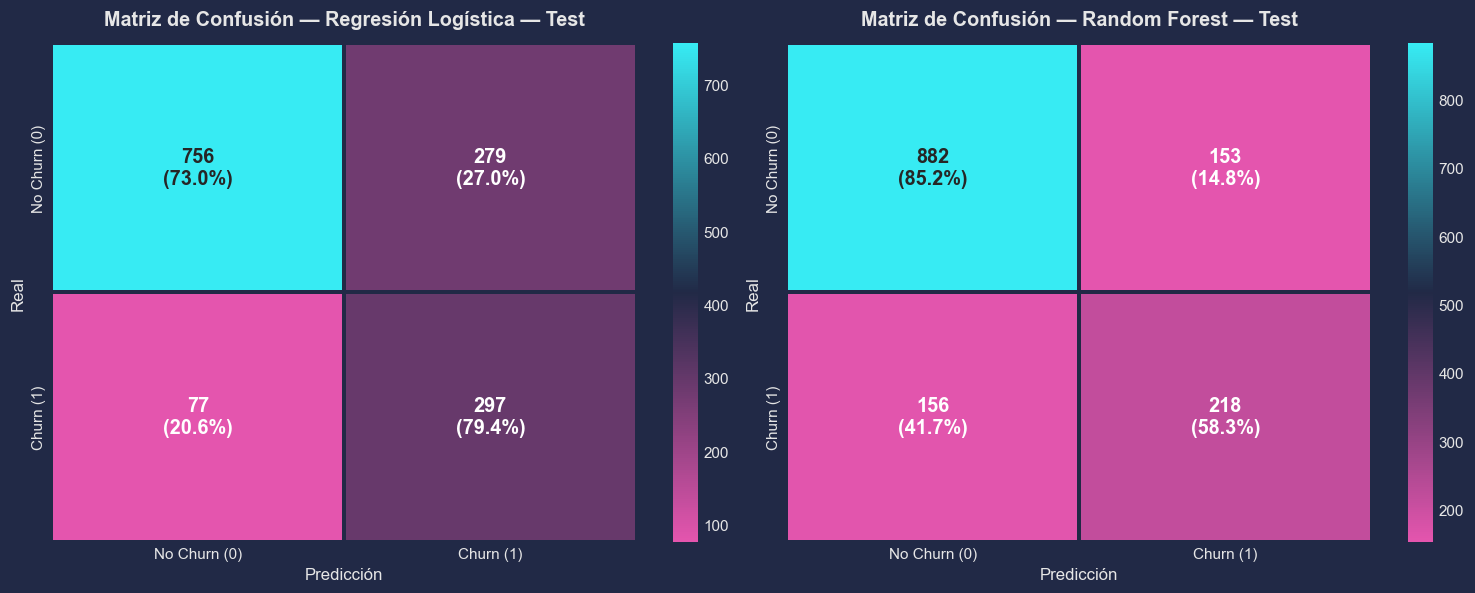

In [13]:
# Matrices de confusión lado a lado para comparación directa
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_confusion_matrix(eval_lr["test"]["cm"], "Regresión Logística — Test", ax=axes[0], show=False)
plot_confusion_matrix(eval_rf["test"]["cm"], "Random Forest — Test", ax=axes[1], show=False)
plt.tight_layout()
plt.show()
plt.close(fig)

### 📈 Curvas ROC — Evaluación Independiente del Umbral

Las curvas **ROC** (Receiver Operating Characteristic) muestran el *trade-off* entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos para **todos los umbrales de decisión posibles**.

- El **AUC** (Area Under the Curve) resume la capacidad discriminativa del modelo en un solo número entre 0.5 (azar) y 1.0 (perfecto).
- A diferencia del F1-Score o la precisión, **no depende del umbral elegido**, por lo que complementa las métricas ya calculadas.

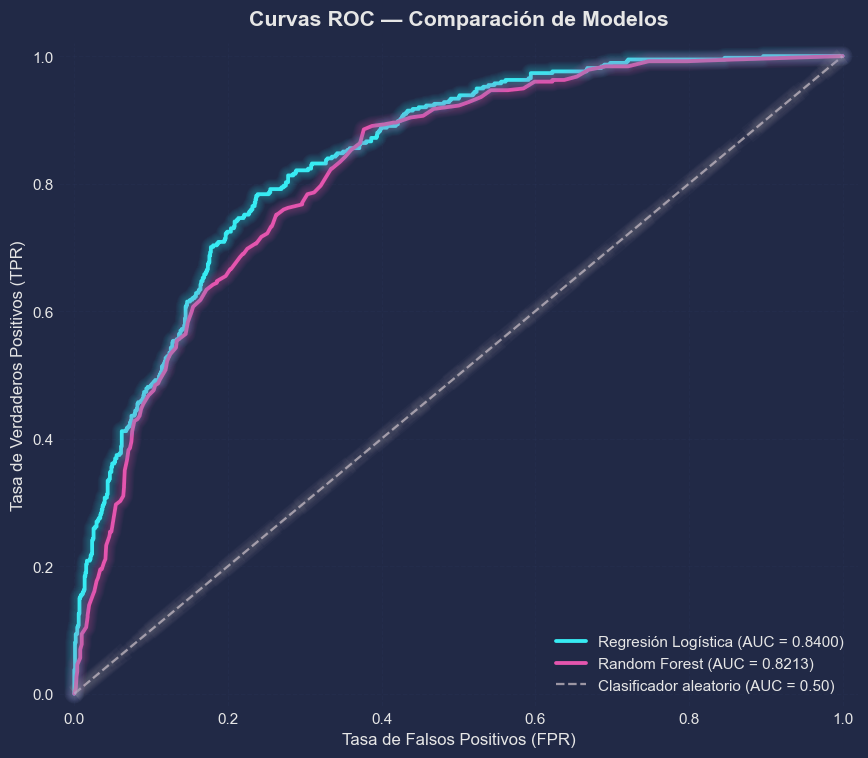

In [14]:
# Curvas ROC comparativas
plot_roc_curves([
    {"name": "Regresión Logística", "y_true": y_test, "y_proba": y_proba_lr},
    {"name": "Random Forest",       "y_true": y_test, "y_proba": y_proba_rf},
])

## 3.4 Comparación de Modelos

¿Cuál de los dos modelos captura mejor a los clientes en riesgo de cancelar? Comparamos las cuatro métricas clave side-by-side para obtener una visión holística del rendimiento.

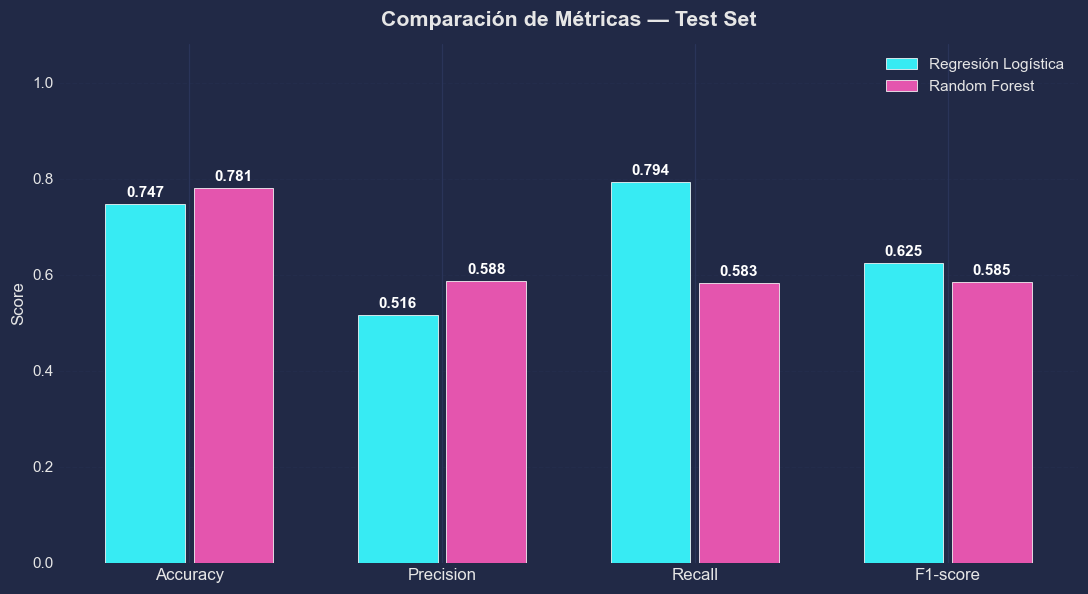


📋 Tabla comparativa — Test Set:



,Regresión Logística,Random Forest
Accuracy,0.7473,0.7807
Precision,0.5156,0.5876
Recall,0.7941,0.5829
F1-score,0.6253,0.5852


In [15]:
# Gráfico comparativo
plot_metrics_comparison([eval_lr, eval_rf])

# Tabla resumen
import pandas as pd

comparison_df = pd.DataFrame(
    {
        result["model"]: {
            "Accuracy": f"{result['test']['accuracy']:.4f}",
            "Precision": f"{result['test']['precision']:.4f}",
            "Recall": f"{result['test']['recall']:.4f}",
            "F1-score": f"{result['test']['f1']:.4f}",
        }
        for result in [eval_lr, eval_rf]
    }
)

print("\n📋 Tabla comparativa — Test Set:\n")
display(comparison_df)

## 3.5 Análisis de Overfitting / Underfitting

Un modelo con **overfitting** obtiene métricas altas en train pero significativamente más bajas en test — ha memorizado los datos de entrenamiento sin aprender patrones generalizables. Por el contrario, **underfitting** se manifiesta cuando ambas métricas (train y test) son bajas — el modelo no captura la estructura subyacente de los datos.

Visualizamos el **gap** (diferencia) entre Train y Test para cada métrica:

- **$\Delta > +0.05$** (rojo): indica overfitting preocupante.
- **$\Delta \leq 0.05$** (verde): generalización saludable.

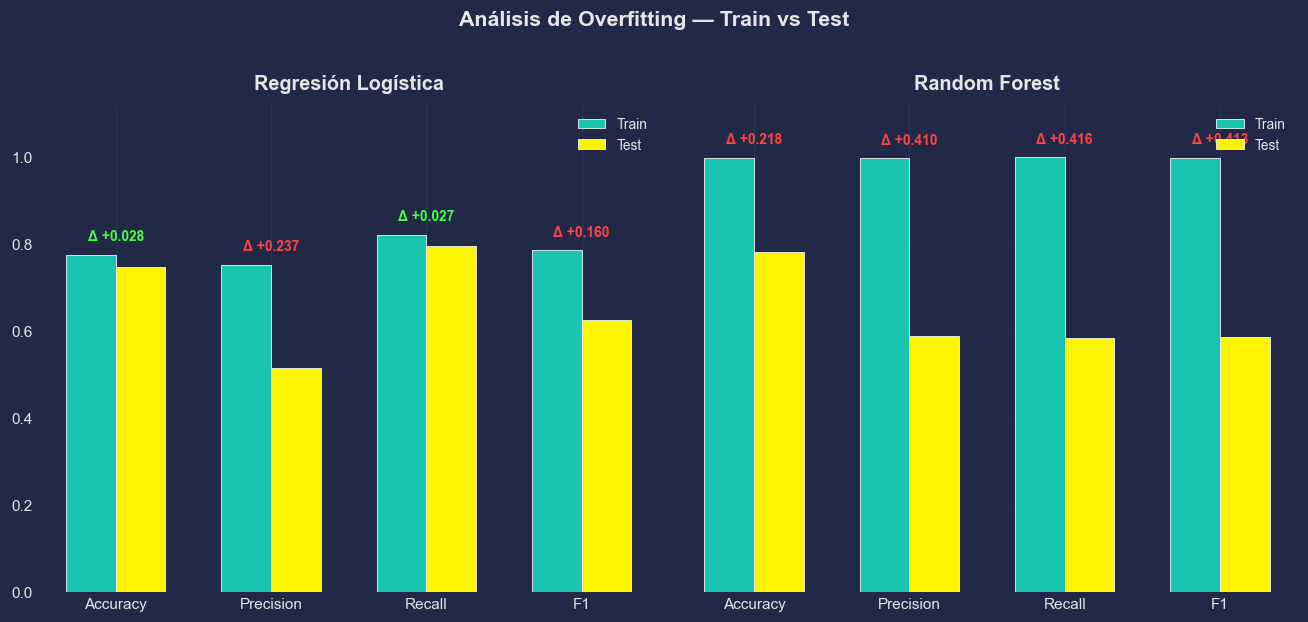

  🔍 Diagnóstico de Overfitting / Underfitting

  ▸ Regresión Logística
    F1 Train : 0.7854
    F1 Test  : 0.6253
    Gap (Δ)  : +0.1601
    ⚠️ Overfitting ALTO — el modelo memoriza el training set.
    → Recomendación: regularizar, reducir profundidad/estimators, o más datos.

  ▸ Random Forest
    F1 Train : 0.9984
    F1 Test  : 0.5852
    Gap (Δ)  : +0.4132
    ⚠️ Overfitting ALTO — el modelo memoriza el training set.
    → Recomendación: regularizar, reducir profundidad/estimators, o más datos.



In [16]:
# Visualización del gap Train vs Test
plot_overfit_analysis([eval_lr, eval_rf])

# Diagnóstico textual
print("=" * 60)
print("  🔍 Diagnóstico de Overfitting / Underfitting")
print("=" * 60)

for result in [eval_lr, eval_rf]:
    name = result["model"]
    if result["train"] is None:
        print(f"\n  {name}: sin datos de train disponibles.")
        continue

    f1_train = result["train"]["f1"]
    f1_test = result["test"]["f1"]
    gap = f1_train - f1_test

    print(f"\n  ▸ {name}")
    print(f"    F1 Train : {f1_train:.4f}")
    print(f"    F1 Test  : {f1_test:.4f}")
    print(f"    Gap (Δ)  : {gap:+.4f}")

    if gap > 0.10:
        print(f"    ⚠️ Overfitting ALTO — el modelo memoriza el training set.")
        print(f"    → Recomendación: regularizar, reducir profundidad/estimators, o más datos.")
    elif gap > 0.05:
        print(f"    🟡 Overfitting MODERADO — gap apreciable pero manejable.")
        print(f"    → Recomendación: considerar ajuste de hiperparámetros o cross-validation.")
    elif f1_test < 0.50:
        print(f"    🔵 Underfitting — rendimiento bajo en ambos conjuntos.")
        print(f"    → Recomendación: modelo más complejo, más features, o revisar datos.")
    else:
        print(f"    ✅ Generalización SALUDABLE — gap mínimo entre train y test.")

print()

In [17]:
# --- Resumen automático del Paso 3 ---

# Determinar modelo ganador por F1
best = max([eval_lr, eval_rf], key=lambda r: r["test"]["f1"])
other = min([eval_lr, eval_rf], key=lambda r: r["test"]["f1"])

f1_diff = best["test"]["f1"] - other["test"]["f1"]

print("=" * 60)
print("  🏆 Resumen del Paso 3: Evaluación de Modelos")
print("=" * 60)
print(f"\n  Modelo con mejor F1-score en test: {best['model']}")
print(f"    F1 = {best['test']['f1']:.4f}  vs  {other['model']} F1 = {other['test']['f1']:.4f}")
print(f"    Ventaja: +{f1_diff:.4f} en F1-score")
print(f"\n  Recall (detección de churners):")
print(f"    {eval_lr['model']}: {eval_lr['test']['recall']:.4f}")
print(f"    {eval_rf['model']}: {eval_rf['test']['recall']:.4f}")

recall_best = max([eval_lr, eval_rf], key=lambda r: r["test"]["recall"])
print(f"\n  → Para retención de clientes, {recall_best['model']} es preferible")
print(f"    por su mayor capacidad de detectar clientes en riesgo.")
print()

  🏆 Resumen del Paso 3: Evaluación de Modelos

  Modelo con mejor F1-score en test: Regresión Logística
    F1 = 0.6253  vs  Random Forest F1 = 0.5852
    Ventaja: +0.0400 en F1-score

  Recall (detección de churners):
    Regresión Logística: 0.7941
    Random Forest: 0.5829

  → Para retención de clientes, Regresión Logística es preferible
    por su mayor capacidad de detectar clientes en riesgo.



---
## ✅ Resumen del Paso 3: Evaluación de Modelos

Se evaluaron ambos modelos con las métricas estándar de clasificación binaria:

| Métrica | Descripción | Se midió en |
|---|---|---|
| **Accuracy** | Aciertos globales | Test |
| **Precision** | Exactitud en predicciones positivas | Test |
| **Recall** | Proporción de churners detectados | Test |
| **F1-score** | Balance Precision-Recall | Test & Train |
| **Confusion Matrix** | Desglose TP/FP/TN/FN | Test |

### Diagnóstico de generalización

Se compararon las métricas de Train vs Test para cada modelo, evaluando:

- **Overfitting**: gap Train-Test > 5% en F1 → el modelo memoriza sin generalizar.
- **Underfitting**: ambas métricas < 50% → el modelo no captura patrones.
- **Generalización saludable**: gap ≤ 5% con métricas razonables.

In [18]:
# --- Persistir resultados de evaluación para Notebook 04 ---
import json
import numpy as np

def _serialize_eval(result: dict) -> dict:
    """Convierte un resultado de evaluación a formato JSON-serializable."""
    out = {"model": result["model"]}
    for split_name in ("test", "train"):
        if result[split_name] is None:
            out[split_name] = None
            continue
        m = {}
        for k, v in result[split_name].items():
            if isinstance(v, np.ndarray):
                m[k] = v.tolist()
            elif isinstance(v, (np.integer, np.floating)):
                m[k] = v.item()
            else:
                m[k] = v
        out[split_name] = m
    return out

eval_export = {
    "models": [_serialize_eval(eval_lr), _serialize_eval(eval_rf)],
    "feature_config": {
        "lr_features": selected_features,
        "rf_features": list(X_train_bal.columns),
    },
}

path = DATA_PROCESSED_DIR / "evaluation_results.json"
with open(path, "w", encoding="utf-8") as f:
    json.dump(eval_export, f, indent=2, ensure_ascii=False)

print(f"✅ Resultados de evaluación exportados: {path.name}")
print(f"   Modelos incluidos: {[r['model'] for r in eval_export['models']]}")

✅ Resultados de evaluación exportados: evaluation_results.json
   Modelos incluidos: ['Regresión Logística', 'Random Forest']
